# Relaicon 5b Nanoelectrónica

In [2]:
### LIBRERIAS ########################

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [3]:
### Constantes universales #######################

hbar = 6.582*10**(-16)     #eV*s

h = 4.1357*10**(-15)        #eV*s

q = 1.602*10**(-19)         #C

kbtz = 8.617*10**(-5)       #eV/K cte de boltzmann 

m0 = 9.1*10**(-31)           #kg

In [4]:
### Definición de parámetros para el ejercicio 2 ############################

T = 1               #K
KT = 0.026*T/300    #eV
L = 40             #nm
W = 3*L             #nm
Ef0 = -5.0          #eV
m=0.5*m0

mu_s0 = Ef0     
mu_d0 = Ef0

G0 = 2 * q / h   # A/V #ya trabajo en unidades naturales asi que no me hace falta el q^2 sino solo q

Cs = 0.0
Cd = 0.0
Cg = 100.0         #aF/nm
CES = (Cs+Cd+Cg)


numpasosE = 4000 

tolerancia = 1e-5
alfa = 0.005
maxiteracion = 200

#Creo el vector de voltajes y las energías

VGS_array = [0.30, 0.35, 0.40, 0.45, 0.50]
VDS_array = np.linspace(0, 0.5, 200)
Ec_modes_0 = -4.7  #eV
numpasosE=4000  #Si pones menos de 3000 las curvas salen woobly, salen no rectas.



In [5]:
### FUNCIONES VERSION 1###############################################

def fermi(energia, e_fermi):
    x = (energia - e_fermi) / (KT + 1e-15)
    x_clipped = np.clip(x, -100.0, 100.0)
    return 1.0 / (1.0 + np.exp(x_clipped))


def densidad_g(energia, Ec):

    if energia > Ec:
        cte = L*W*1e-18*m/(np.pi*hbar**2*q)
        return cte
    else:
        return 0.0


def funcion_N(energia, Ec_aux, U, mus, mud):

    aux = densidad_g(energia + U, Ec_aux) * 0.5 * (fermi(energia, mus) + fermi(energia, mud))
    
    return aux


def funcion_I(energia, Ec_aux, U, mus, mud):

    if energia + U > Ec_aux:
        
        cte = W*1e-9/(np.pi**2*hbar**2)*np.sqrt(2*m*q)
        func = cte*np.sqrt(energia-Ec_aux+U)*(fermi(energia,mus)-fermi(energia,mud))
        return func
    else:
        return 0.0

In [ ]:
### CÓDIGO EJERCICIO 4 ################################

T=1
KT = 0.026*T/300    #eV

tolerancia = 1e-5
alfa = 0.02

#Capacidad total
CES = Cg + Cs + Cd
#Calculo numero de electrones en equilibrio

mu_s0 = Ef0
mu_d0 = Ef0
U0 = 0.0
Emin0 = min((Ec_modes_0), mu_s0, mu_d0) - 0.2
Emax0 = max((Ec_modes_0), mu_s0, mu_d0) + 0.2
E = np.linspace(Emin0, Emax0, numpasosE)

integrando_N = np.array([funcion_N(energia, Ec_modes_0, U0, mu_s0, mu_d0) for energia in E])
num_e0 = np.trapz(integrando_N, E)


#Ahora hago el bucle total igual que antes, pero le metro otro para la autoconsistencia.
IDS_total = []

for VGS in VGS_array:
    
    IDS_VDS = []
    
    for VDS in VDS_array:
        
        mu_s = Ef0
        mu_d = Ef0 - VDS
        Ec_eff = Ec_modes_0 #Ya tengo en cuenta el efecto de U, lo uso ahora solo por notacion

        Emin = min(np.min(Ec_eff), mu_d, mu_s) - 0.2
        Emax = max(np.max(Ec_eff), mu_d, mu_s) + 0.2
        E = np.linspace(Emin, Emax, numpasosE)
        
        #Semilla sin tener en cuenta el charging
        U_old = VGS*Cg/CES + VDS*Cd/CES

        error = 1.0
        numiteracion = 0

        while error > tolerancia and numiteracion < maxiteracion:
            
        
            # Cálculo de N con el U actual
            integrando_N = np.array([funcion_N(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
            num_e = np.trapezoid(integrando_N, E)
            
            
            #Calculo el nuevo valor de U teórico
            U_aux = VGS*Cg/CES + VDS*Cd/CES - q/(CES*1e-18) * (num_e - num_e0)
            #Le meto el alfa igual que en la relación 3 y calculo el nuevo valor de U
            U_new = U_old + alfa*(U_aux - U_old)
            #error para ver si ha convergido suficiente
            error = np.abs(U_new - U_old)
            U_old = U_new
            numiteracion += 1

        # Corriente con U convergido
        integrando_I = np.array([funcion_I(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
        i_aux = np.trapezoid(integrando_I, E)
        #Salimos del bucle y meto la intensidad de Vds
        IDS_VDS.append(i_aux)
    #Salimos del bucle y meto la curva de intensidad para un VGS
    IDS_total.append(IDS_VDS)
    print(f"{VGS} hecho")
    
#Lo pongo como np para que tarde menos en plotear
IDS_total = np.array(IDS_total, dtype=float)

0.3 hecho
0.35 hecho
0.4 hecho
0.45 hecho
0.5 hecho


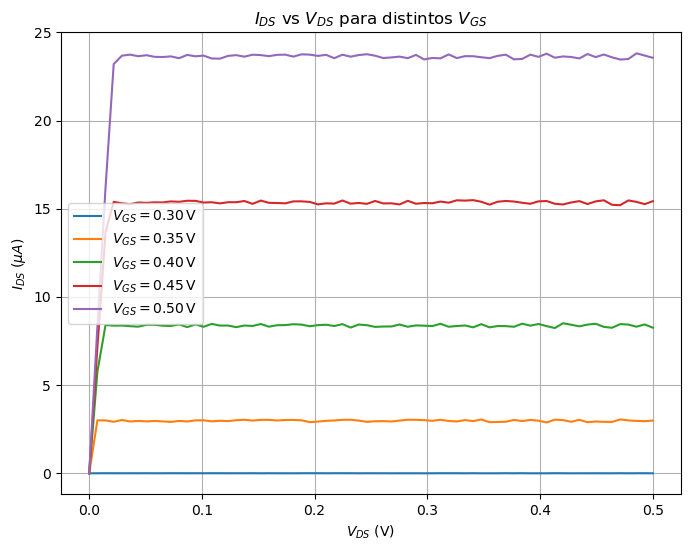

In [ ]:
### PLOT DEL EJERCICIO #####################

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*10**6, label=rf"$V_{{GS}}={VGS:.2f}\,$V")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"$I_{DS}$ vs $V_{DS}$ para distintos $V_{GS}$")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
### CÓDIGO EJERCICIO 4  T=298 ################################



T=298
KT = 0.026*T/300    #eV

#Capacidad total
CES = Cg + Cs + Cd
#Calculo numero de electrones en equilibrio

mu_s0 = Ef0
mu_d0 = Ef0
U0 = 0.0
Emin0 = min((Ec_modes_0), mu_s0, mu_d0) - 0.2
Emax0 = max((Ec_modes_0), mu_s0, mu_d0) + 0.2
E = np.linspace(Emin0, Emax0, numpasosE)

integrando_N = np.array([funcion_N(energia, Ec_modes_0, U0, mu_s0, mu_d0) for energia in E])
num_e0 = np.trapezoid(integrando_N, E)


#Ahora hago el bucle total igual que antes, pero le metro otro para la autoconsistencia.
IDS_total = []

for VGS in VGS_array:
    
    IDS_VDS = []
    
    for VDS in VDS_array:
        
        mu_s = Ef0
        mu_d = Ef0 - VDS
        Ec_eff = Ec_modes_0 #Ya tengo en cuenta el efecto de U, lo uso ahora solo por notacion

        Emin = min(np.min(Ec_eff), mu_d, mu_s) - 0.2
        Emax = max(np.max(Ec_eff), mu_d, mu_s) + 0.2
        E = np.linspace(Emin, Emax, numpasosE)
        
        #Semilla sin tener en cuenta el charging
        U_old = VGS*Cg/CES + VDS*Cd/CES

        error = 1.0
        numiteracion = 0

        while error > tolerancia and numiteracion < maxiteracion:
            
        
            # Cálculo de N con el U actual
            integrando_N = np.array([funcion_N(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
            num_e = np.trapezoid(integrando_N, E)
            
            
            #Calculo el nuevo valor de U teórico
            U_aux = VGS*Cg/CES + VDS*Cd/CES - q/(CES*1e-18) * (num_e - num_e0)
            #Le meto el alfa igual que en la relación 3 y calculo el nuevo valor de U
            U_new = U_old + alfa*(U_aux - U_old)
            #error para ver si ha convergido suficiente
            error = np.abs(U_new - U_old)
            U_old = U_new
            numiteracion += 1

        # Corriente con U convergido
        integrando_I = np.array([funcion_I(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
        i_aux = np.trapezoid(integrando_I, E)
        #Salimos del bucle y meto la intensidad de Vds
        IDS_VDS.append(i_aux)
    #Salimos del bucle y meto la curva de intensidad para un VGS
    IDS_total.append(IDS_VDS)
    print(f"{VGS} hecho")
    
#Lo pongo como np para que tarde menos en plotear
IDS_total = np.array(IDS_total, dtype=float)

0.3 hecho
0.35 hecho
0.4 hecho
0.45 hecho
0.5 hecho


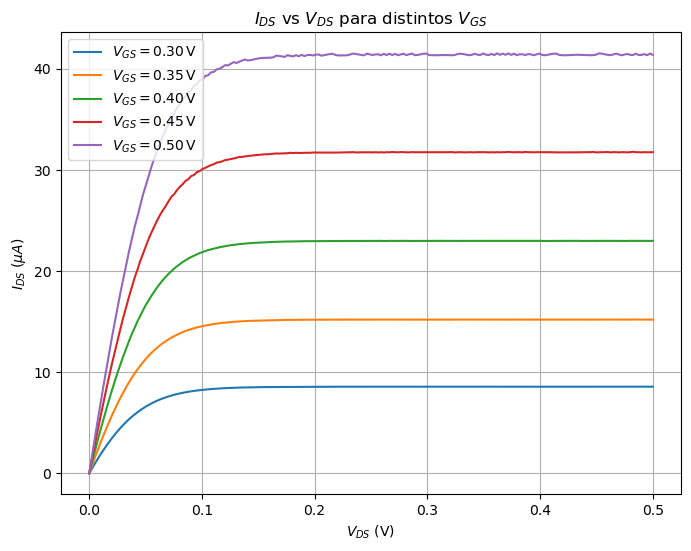

In [8]:
### PLOT DEL EJERCICIO #####################

plt.figure(figsize=(8,6))

for i, VGS in enumerate(VGS_array):
    plt.plot(VDS_array, IDS_total[i]*10**6, label=rf"$V_{{GS}}={VGS:.2f}\,$V")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ $(\mu A)$")
plt.title(r"$I_{DS}$ vs $V_{DS}$ para distintos $V_{GS}$")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
### Apartado C #####

T = 298
KT = 0.026*T/300    # eV


#Ahora voy hasta 1V porque inicialmente lo puse en 5V y saturaba mucho antes.
VGS_array = np.linspace(0.0, 1.0, 100)
VDS = 0.5 #Fijo el VDS

CES = Cg + Cs + Cd


#Cambio los parámetros porque tarda mucho menos
numpasosE = 4000
maxiteracion = 200
alfa = 0.05

#Electrones en equilibrio
mu_s0 = Ef0
mu_d0 = Ef0
U0 = 0.0

#Esto lo hacía antes dentro del bucle, ahora lo pongo fuera. Amplío la energía mínima y máxima en +1
Emin0 = min(np.min(Ec_modes_0), mu_s0, mu_d0) - 1.0
Emax0 = max(np.max(Ec_modes_0), mu_s0, mu_d0) + 1.0
E = np.linspace(Emin0, Emax0, numpasosE)

integrando_N = np.array([funcion_N(energia, Ec_modes_0, U0, mu_s0, mu_d0) for energia in E])
num_e0 = np.trapezoid(integrando_N, E)

IDS_total = []

#Solo barro en VGS no en VDS.

for VGS in VGS_array:
    
    mu_s = Ef0
    mu_d = Ef0 - VDS
    Ec_eff = Ec_modes_0

    Emin = min(np.min(Ec_eff) - 1.0, mu_d, mu_s) - 0.2
    Emax = max(np.max(Ec_eff) + 1.0, mu_d, mu_s) + 0.2
    E = np.linspace(Emin, Emax, numpasosE)

    U_old = VGS*Cg/CES + VDS*Cd/CES

    error = 1.0
    numiteracion = 0

    while error > tolerancia and numiteracion < maxiteracion:

        integrando_N = np.array([funcion_N(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
        num_e = np.trapezoid(integrando_N, E)

        U_aux = VGS*Cg/CES + VDS*Cd/CES - q/(CES) * (num_e - num_e0)

        U_new = U_old + alfa*(U_aux - U_old)

        error = np.abs(U_new - U_old)
        U_old = U_new
        numiteracion += 1

    integrando_I = np.array([funcion_I(energia, Ec_eff, U_old, mu_s, mu_d) for energia in E])
    i_aux = np.trapezoid(integrando_I, E)

    IDS_total.append(i_aux)

    print(f"{VGS} hecho, I = {i_aux:.10f}")

IDS_total = np.array(IDS_total)

0.0 hecho, I = 0.0000000004
0.010101010101010102 hecho, I = 0.0000000005
0.020202020202020204 hecho, I = 0.0000000008
0.030303030303030304 hecho, I = 0.0000000011
0.04040404040404041 hecho, I = 0.0000000017
0.05050505050505051 hecho, I = 0.0000000025
0.06060606060606061 hecho, I = 0.0000000037
0.07070707070707072 hecho, I = 0.0000000055
0.08080808080808081 hecho, I = 0.0000000081
0.09090909090909091 hecho, I = 0.0000000120
0.10101010101010102 hecho, I = 0.0000000178
0.11111111111111112 hecho, I = 0.0000000263
0.12121212121212122 hecho, I = 0.0000000388
0.13131313131313133 hecho, I = 0.0000000574
0.14141414141414144 hecho, I = 0.0000000849
0.15151515151515152 hecho, I = 0.0000001253
0.16161616161616163 hecho, I = 0.0000001853
0.17171717171717174 hecho, I = 0.0000002738
0.18181818181818182 hecho, I = 0.0000004045
0.19191919191919193 hecho, I = 0.0000005971
0.20202020202020204 hecho, I = 0.0000008805
0.21212121212121213 hecho, I = 0.0000012959
0.22222222222222224 hecho, I = 0.0000019065
0

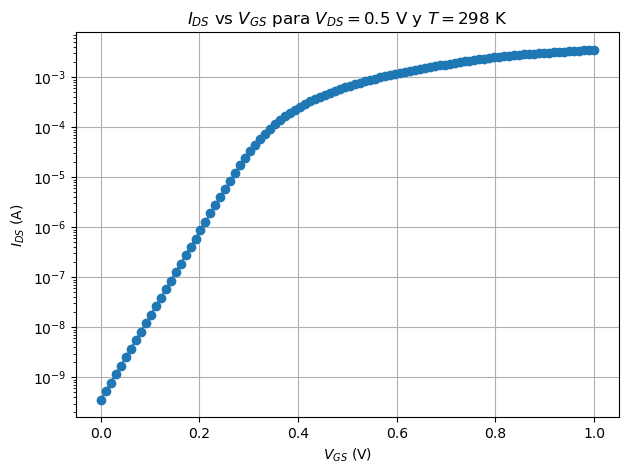

In [7]:
### PLOT ##############################

plt.figure(figsize=(7,5))
plt.semilogy(VGS_array, np.abs(IDS_total), 'o-')

plt.xlabel(r'$V_{GS}$ (V)')
plt.ylabel(r'$I_{DS}$ (A)')
plt.title(r'$I_{DS}$ vs $V_{GS}$ para $V_{DS}=0.5$ V y $T=298$ K')
plt.grid(True)

plt.show()

In [8]:
### PENDIENTE SUBUMBRAL ###############


#Pongo los límites que hay hasta que se vea recto. V1 es el mínimo y V2 el máximo
V1 = 0.05 
V2 = 0.25

#Cojo dichos puntos, modo máscara
buenos = (VGS_array > V1) & (VGS_array < V2) & (IDS_total > 0)

#Modifico los arrays para que tengan solo esos puntos y lo pongo en lgaritmo la intensidad.
x = VGS_array[buenos]
y = np.log10(IDS_total[buenos])

coef = np.polyfit(x, y, 1)

#Me interesa la pendiente pero S es la inversa. Lo calculo y lo imprimo.
pendiente = coef[0]
S = 1/pendiente

print("Pendiente =", pendiente, "dec/V")
print("S =", S, "V/dec")
print("S =", S*1000, "mV/dec")

Pendiente = 16.760727006502048 dec/V
S = 0.059663283079073266 V/dec
S = 59.66328307907327 mV/dec
